In [1]:
import pandas as pd
df_all_shuffled_training_mass = pd.read_csv("event_candidate_dataset_training.csv")
print(df_all_shuffled_training_mass.head())

   EvID  N Electron candidates  N Muon candidates  N Pion candidates  \
0     0                      0                  0                  1   
1     1                      0                  1                  0   
2     2                      0                  1                  0   
3     3                      0                  0                  0   
4     4                      0                  0                  0   

   N Kaon candidates  N Proton candidates  N Tracks  Invariant Mass  
0                  1                    1         2        3.148777  
1                  0                    1         2        3.079605  
2                  1                    0         2        3.126244  
3                  1                    0         2        3.051369  
4                  0                    1         2        3.073080  


In [2]:
df_all_shuffled_training_mass.info()

<class 'pandas.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   EvID                   80000 non-null  int64  
 1   N Electron candidates  80000 non-null  int64  
 2   N Muon candidates      80000 non-null  int64  
 3   N Pion candidates      80000 non-null  int64  
 4   N Kaon candidates      80000 non-null  int64  
 5   N Proton candidates    80000 non-null  int64  
 6   N Tracks               80000 non-null  int64  
 7   Invariant Mass         80000 non-null  float64
dtypes: float64(1), int64(7)
memory usage: 4.9 MB


In [3]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
#------------------------------------------
# 1. Load and Prepare the Data
#------------------------------------------

X=df_all_shuffled_training_mass[['N Electron candidates', 'N Muon candidates', 'N Pion candidates', 'N Kaon candidates', 'N Proton candidates', 'N Tracks']].values
# Extract mass separately
# mass = df['Invariant Mass'].values

mass = df_all_shuffled_training_mass['Invariant Mass'].values
# Create a train/test split

X_train, X_test, mass_train, mass_test = train_test_split(X, mass, test_size=0.05, random_state=42)

I0000 00:00:1780321865.916779   76950 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780321865.954935   76950 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780321866.725253   76950 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
from sklearn.preprocessing import MinMaxScaler
#Initialize scaler

scaler = MinMaxScaler()
#Fit and transform training data, transform test data

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
print(X_train.shape, X_test.shape)

(76000, 6) (4000, 6)


In [6]:
import tensorflow as tf
print("TensorFlow version:", tf.version)
print("Available devices:", tf.config.list_physical_devices())

TensorFlow version: <module 'tensorflow._api.v2.version' from '/home/student/tbml/.venv/lib/python3.12/site-packages/tensorflow/_api/v2/version/__init__.py'>
Available devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


E0000 00:00:1780321867.141006   76950 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1" # Disable GPU (if any)
#------------------------------------------
# 2. Define the Autoencoder Model
#------------------------------------------

input_dim = X_train.shape[1] # should be 6
encoding_dim = 4 # latent space dimension
# Input layer

input_layer = Input(shape=(input_dim,))
# Encoding layer (compression)

encoded = Dense(encoding_dim, activation='relu')(input_layer)
# Decoding layer (reconstruction)

decoded = Dense(input_dim, activation='sigmoid')(encoded)
# Autoencoder model

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')

In [8]:
from tensorflow.keras.optimizers import Adam
autoencoder.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
# autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse') # best, 185 epochs automatic stop

In [9]:
#------------------------------------------
#3. Train the Autoencoder
#------------------------------------------

early_stopping = EarlyStopping(
monitor='val_loss',
patience=2,
restore_best_weights=True
)

history = autoencoder.fit(X_train, X_train,
epochs=500,
# epochs=500,
batch_size=256,
# batch_size=64,
shuffle=True,
validation_data=(X_test, X_test),
verbose=2,
callbacks=[early_stopping]
)
# with tf.device('/CPU:0'):
#     history = autoencoder.fit(X_train, X_train,
#     epochs=500,
#     batch_size=64,
#     validation_data=(X_test, X_test),
#     callbacks=[early_stopping],
#     verbose=2)

Epoch 1/500
297/297 - 1s - 2ms/step - loss: 0.0488 - val_loss: 0.0112
Epoch 2/500
297/297 - 0s - 730us/step - loss: 0.0086 - val_loss: 0.0066
Epoch 3/500
297/297 - 0s - 697us/step - loss: 0.0060 - val_loss: 0.0058
Epoch 4/500
297/297 - 0s - 690us/step - loss: 0.0055 - val_loss: 0.0054
Epoch 5/500
297/297 - 0s - 700us/step - loss: 0.0052 - val_loss: 0.0052
Epoch 6/500
297/297 - 0s - 899us/step - loss: 0.0049 - val_loss: 0.0049
Epoch 7/500
297/297 - 0s - 742us/step - loss: 0.0045 - val_loss: 0.0043
Epoch 8/500
297/297 - 0s - 727us/step - loss: 0.0038 - val_loss: 0.0037
Epoch 9/500
297/297 - 0s - 773us/step - loss: 0.0032 - val_loss: 0.0030
Epoch 10/500
297/297 - 0s - 676us/step - loss: 0.0026 - val_loss: 0.0025
Epoch 11/500
297/297 - 0s - 680us/step - loss: 0.0022 - val_loss: 0.0022
Epoch 12/500
297/297 - 0s - 911us/step - loss: 0.0019 - val_loss: 0.0020
Epoch 13/500
297/297 - 0s - 804us/step - loss: 0.0018 - val_loss: 0.0019
Epoch 14/500
297/297 - 0s - 786us/step - loss: 0.0017 - val_lo

In [10]:
print(f"Training stopped at epoch {len(history.history['loss'])}")
print(f"Training stopped at epoch {len(history.history['loss'])}")

Training stopped at epoch 52
Training stopped at epoch 52


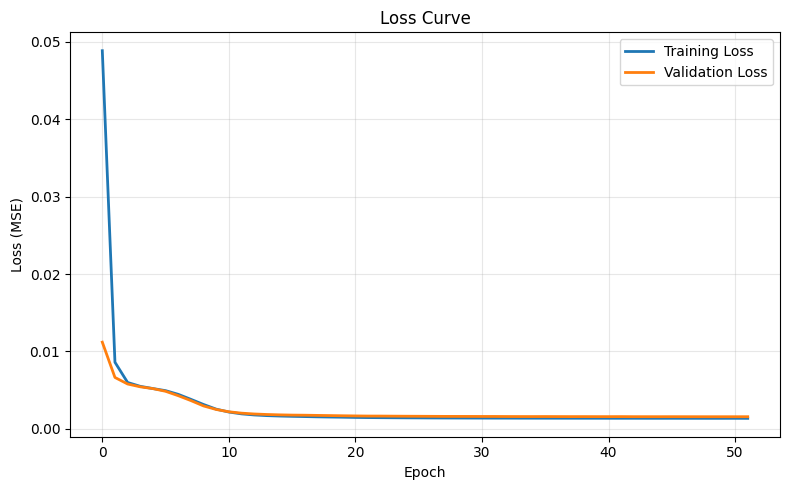

In [11]:
import matplotlib.pyplot as plt

# Training history

train_loss = history.history['loss']
val_loss = history.history['val_loss']

# Create loss curve
plt.figure(figsize=(8, 5))
plt.plot(train_loss, label='Training Loss', linewidth=2)
plt.plot(val_loss, label='Validation Loss', linewidth=2)

plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


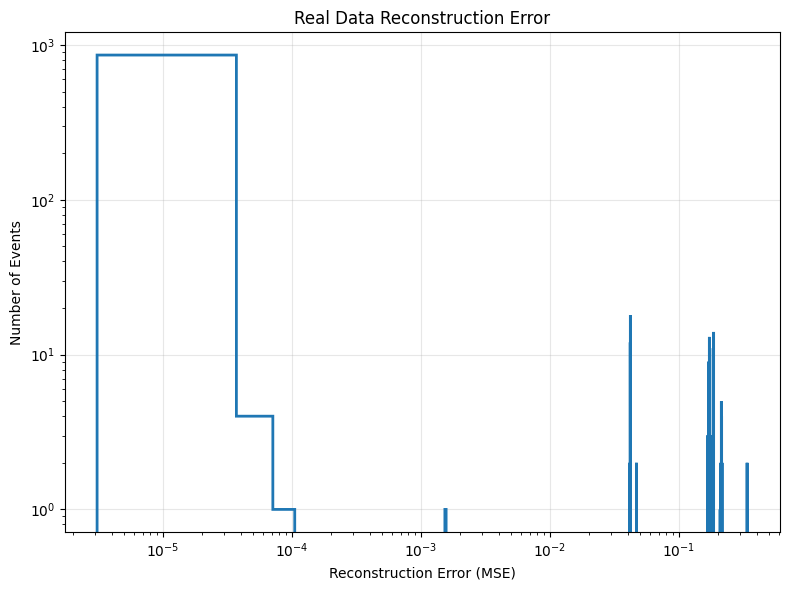

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------
# Load real data
# ------------------------------------------
df_real = pd.read_csv("event_candidate_dataset_real.csv")

# Keep only the same features used during training
# Replace feature_columns with your actual feature list
X_real = df_real[['N Electron candidates', 'N Muon candidates', 'N Pion candidates', 'N Kaon candidates', 'N Proton candidates', 'N Tracks']].values

# Apply the SAME scaling used during training
X_real_scaled = scaler.transform(X_real)

# ------------------------------------------
# Reconstruction
# ------------------------------------------
X_real_pred = autoencoder.predict(X_real_scaled, batch_size=256)

# Event-by-event reconstruction error
reconstruction_error = np.mean(
    np.square(X_real_scaled - X_real_pred),
    axis=1
)

# ------------------------------------------
# Plot histogram
# ------------------------------------------
plt.figure(figsize=(8,6))

counts, bin_edges, _ = plt.hist(
    reconstruction_error,
    bins=10000,
    histtype='step',
    linewidth=2
)
plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Number of Events")
plt.title("Real Data Reconstruction Error")
plt.yscale("log")  # often useful for anomaly searches
plt.xscale("log")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


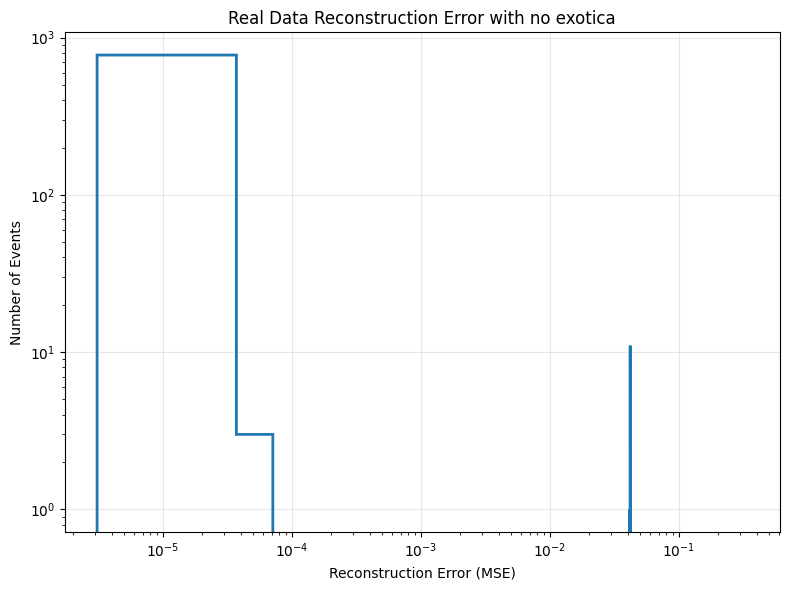

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------
# Load real data
# ------------------------------------------
df_real_noex = pd.read_csv("event_candidate_dataset_real-noexotica.csv")

# Keep only the same features used during training
# Replace feature_columns with your actual feature list
X_real_noex = df_real_noex[['N Electron candidates', 'N Muon candidates', 'N Pion candidates', 'N Kaon candidates', 'N Proton candidates', 'N Tracks']].values

# Apply the SAME scaling used during training
X_real_scaled_noex = scaler.transform(X_real_noex)

# ------------------------------------------
# Reconstruction
# ------------------------------------------
X_real_pred_noex = autoencoder.predict(X_real_scaled_noex, batch_size=256)

# Event-by-event reconstruction error
reconstruction_error_noex = np.mean(
    np.square(X_real_scaled_noex - X_real_pred_noex),
    axis=1
)

# ------------------------------------------
# Plot histogram
# ------------------------------------------
plt.figure(figsize=(8,6))

plt.hist(
    reconstruction_error_noex,
    bins=bin_edges,
    histtype='step',
    linewidth=2
)

plt.xlabel("Reconstruction Error (MSE)")
plt.ylabel("Number of Events")
plt.title("Real Data Reconstruction Error with no exotica")
plt.yscale("log")  
plt.xscale("log")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

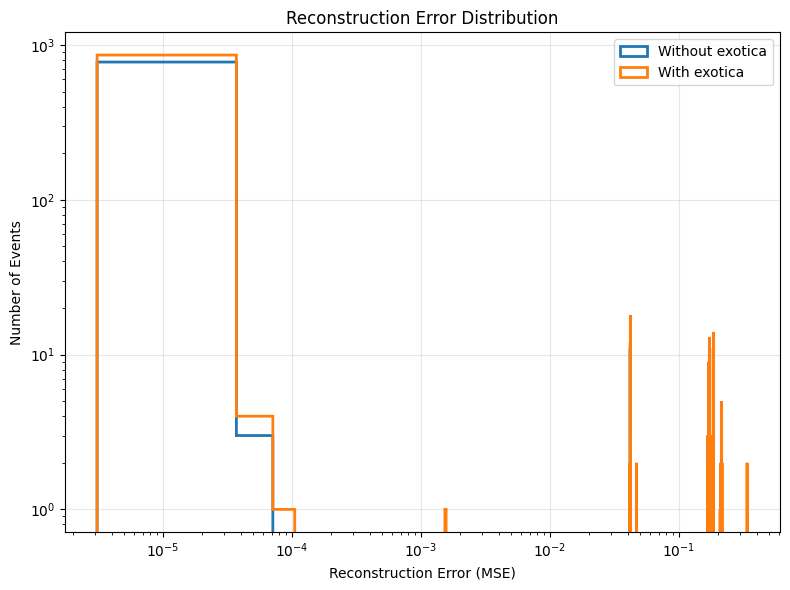

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.hist(
    reconstruction_error_noex,
    bins=bin_edges,
    histtype='step',
    linewidth=2,
    label='Without exotica'
)

plt.hist(
    reconstruction_error,
    bins=bin_edges,
    histtype='step',
    linewidth=2,
    label='With exotica'
)

plt.xlabel('Reconstruction Error (MSE)')
plt.ylabel('Number of Events')
plt.title('Reconstruction Error Distribution')
plt.legend()
plt.grid(alpha=0.3)

plt.yscale('log')
plt.xscale("log")
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd

df_combined = pd.DataFrame({
    "Invariant Mass": df_real["Invariant Mass"].values,
    "reconstruction_error": reconstruction_error
})

df_combined.tail()

,Invariant Mass,reconstruction_error
995,4.339749,0.171221
996,4.333780,0.185928
997,4.297647,0.183661
998,4.371075,0.214501
999,4.342216,0.170123


In [16]:
import pandas as pd

df_combined_noex = pd.DataFrame({
    "Invariant Mass": df_real_noex["Invariant Mass"].values,
    "reconstruction_error_noex": reconstruction_error_noex
})

df_combined_noex.tail()

,Invariant Mass,reconstruction_error_noex
795,2.317141,0.000005
796,1.486178,0.000011
797,1.392323,0.000012
798,1.992836,0.000011
799,1.118474,0.000011


In [17]:
threshold = 0.5e-4

df_cut = df_combined[df_combined["reconstruction_error"] > threshold]
df_cut_noex = df_combined_noex[df_combined_noex["reconstruction_error_noex"] > threshold]

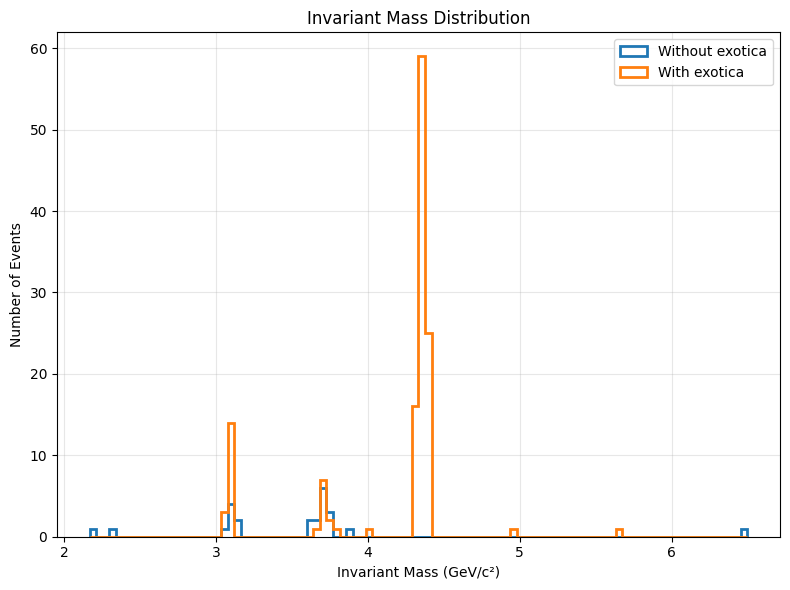

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

counts2, bin_edges2, _ = plt.hist(
    df_cut_noex["Invariant Mass"],
    bins=100,
    histtype='step',
    linewidth=2,
    label='Without exotica'
)

plt.hist(
    df_cut["Invariant Mass"],
    bins=bin_edges2,
    histtype='step',
    linewidth=2,
    label='With exotica'
)

plt.xlabel("Invariant Mass (GeV/c²)")
plt.ylabel("Number of Events")
plt.title("Invariant Mass Distribution")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()